## 0. Import and Definitions

In [ ]:
import os
import copy
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA

from src.model.config import VAEConfig
from src.model.build_model import get_model

from src.model.VAE.VAE_model import (
    SCVIMixturePriorWrapper,
    MixturePriorSCVI,
    assign_cluster_idx,
)

from src.model.data_utils import (
    prepare_train_test_data,
    load_data,
    load_metacells,
    prepare_data,
    get_condition_vocab,
    split_holdout_combinations,
)

from src.analysis.mmd import gaussian_kernel, mmd, ctrl_mmd_dists, mmd_dists, plot_mmd_dists

from src.analysis.logistic_regression import (
    init_classifier, 
    train_classifier, 
    evaluate_cfs_classification, 
    evaluate_training_error, 
    generate_counterfactuals_scvi,
)

from src.analysis.analysis_utils import Analyzer
from src.analysis.cf_expressions import (
    plot_mean_expression_comparison,
    plot_effect_size_comparison,
    plot_top_deg_violin,
)
from src.analysis.INN_OOD import (
    estimate_leftout_combo_mean,
    sample_leftout_combo_normal,
    sample_leftout_combo_shift,
    scoped_analyzer_for_combo,
    cfs_fn_from_adata,
    evaluate_leftout_combo_mmd,
)


## 1. Load Data

In [ ]:
dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

USE_METACELLS = True
DONOR = ["Donor1"]

if not USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=False,
        cell_types=["CD4 Memory"],
    )
else:
    # log_transform=False: MixturePriorSCVI registers layer="counts" (always raw) for
    # training, but analyzer.adata.X is also used directly as the raw-count ground
    # truth by SCVIMixturePriorWrapper's default normalize_output=False. load_metacells
    # also skips load_data entirely (not just SEACells) once a cache for this (dataset,
    # top_genes, donors, group_keys) combination exists on disk - shared with
    # eoflow.ipynb/mean.ipynb's own load_metacells calls regardless of their different
    # log_transform, since metacell construction never depends on it.
    adata, labels_key, control_label = load_metacells(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        ["cell_type", "cytokine"],
        donors=DONOR,
        log_transform=False,
    )
    print(adata.X.shape)

dataset_args["top_genes"] = min(adata.shape[1], dataset_args["top_genes"])

In [3]:
combo_conditions = [labels_key, "cell_type"]
HOLDOUT_COMBO = {labels_key: "IL-2", "cell_type": "CD8 Memory"}

if HOLDOUT_COMBO is not None:
    assert USE_METACELLS, "Holding out a combo requires USE_METACELLS=True."

# fixed pre-holdout vocabulary, so the held-out combo still reserves a slot instead of
# vanishing once its rows are removed below
condition_categories, combo_categories = get_condition_vocab(adata, combo_conditions)

if HOLDOUT_COMBO is not None:
    train_adata, _ = split_holdout_combinations(adata, [HOLDOUT_COMBO], group_keys=combo_conditions)
    print(f"Held out combo {HOLDOUT_COMBO}; training on the remaining {train_adata.n_obs} metacells.")
else:
    train_adata = adata

# populated once here (rather than inside get_VAE) so it's set up for both the
# training path (2.1) and the load-only path (2.2), which bypasses get_VAE entirely
assign_cluster_idx(train_adata, conditions=combo_conditions, combo_categories=combo_categories)

model_path = "/g/stegle/jhoefer/models/cvae"
if HOLDOUT_COMBO is not None:
    combo_str = "_".join(f"{k}-{v.replace(' ', '-')}" for k, v in HOLDOUT_COMBO.items())
    model_path = os.path.join(model_path, f"holdout_{combo_str}")

Held out combo {'cytokine': 'IL-2', 'cell_type': 'CD8 Memory'}; training on the remaining 10088 metacells.


## 2. Model

### 2.1 Training

In [4]:
beta = 0.01
lr_means = 1e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = VAEConfig(
    N_dim=train_adata.X.shape[1],
    means_seperation=4.0,
    trainable_means=True,
    trainable_sigma=False,
    beta=beta,
    lr_means=lr_means,
    conditions=combo_conditions,
    combo_categories=combo_categories,
)

In [5]:
cvae_model, _ = get_model(config, train_adata)

cvae_model.train(
    max_epochs=300,
    plan_kwargs={"lr_means": lr_means, "means_warmup_epochs": 30},
)

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 8 in adata.obs['_scvi_cluster_idx'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jhoefer/sandbox/.venv/lib/python3.11/site-pack ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/lightning/fabric/plugins/e

Training:   0%|          | 0/300 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


In [6]:
cvae_model.model.save(model_path, overwrite=True)
os.rename(model_path + "/model.pt", model_path + f"/{beta}_beta_{lr_means}_lr_means_model.pt")

### 2.2 Loading

In [ ]:
model = MixturePriorSCVI.load(model_path, adata=train_adata, prefix=f"{beta}_beta_{lr_means}_lr_means_")
cvae_model = SCVIMixturePriorWrapper(model).to(device)

## 3. Evaluation

### 3.1 Paths

In [7]:
plot_dir = f"/home/jhoefer/sandbox/results/cvae/plots/{beta}_beta_{lr_means}_lr_means"
csv_dir = f"/home/jhoefer/sandbox/results/cvae/csv/{beta}_beta_{lr_means}_lr_means"
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

### 3.2 Loss

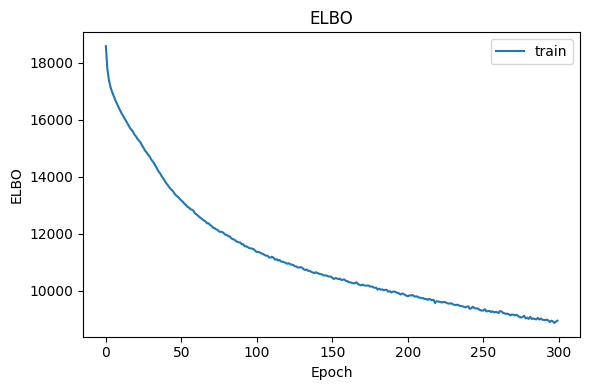

In [9]:
def plot_metric(hist, train_key, title, ylabel, val_key=None):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    if val_key is not None:
        plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"{title}.png"))
    plt.show()

hist = cvae_model.model.history
if "elbo_train" in hist:
    plot_metric(hist, "elbo_train", "ELBO","ELBO")

### 3.3 Clusters

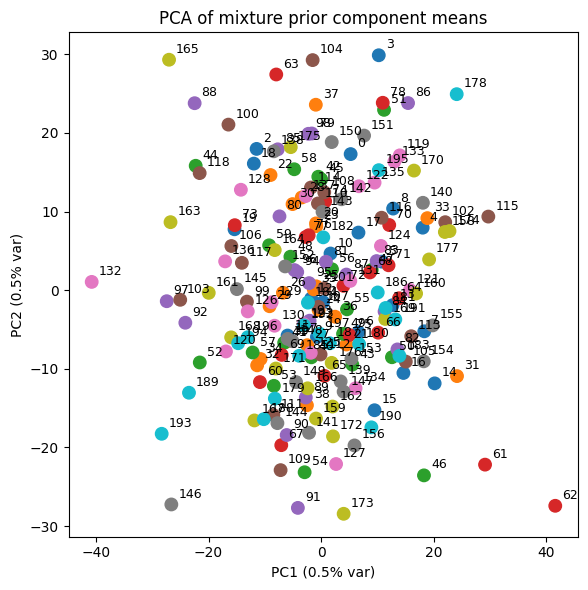

In [10]:
# pull the parameter out to a plain numpy array
means = cvae_model.means_active.detach().cpu().numpy()  # shape: (n_components, n_latent)

# PCA down to 2D
pca = PCA(n_components=2)
means_2d = pca.fit_transform(means)

# plot, labeling each point by its component index
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(means_2d[:, 0], means_2d[:, 1], s=80, c=np.arange(len(means)), cmap="tab10")

for i, (x, y) in enumerate(means_2d):
    ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(5, 5), fontsize=9)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("PCA of mixture prior component means")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "mixture_prior_means_pca.png"))
plt.show()

KeyboardInterrupt: 

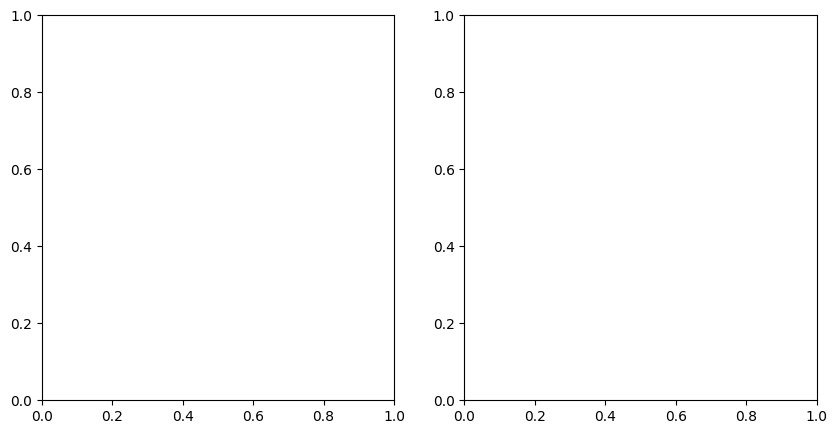

In [11]:
Z_cvae = cvae_model.model.get_latent_representation()
# train_adata, not adata - get_latent_representation() with no argument returns latent
# for whatever adata the model is registered on, which is train_adata (holdout-excluded,
# fewer rows than the full adata) once a combo is held out
train_adata.obsm["Z_cvae"] = Z_cvae


reps = ["Z_cvae"]
titles = ["Z_cvae"]

colors = [f"{labels_key}", "cell_type"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for i, rep in enumerate(reps):
    sc.pp.neighbors(train_adata, use_rep=rep)
    sc.tl.umap(train_adata)

    for j, color in enumerate(colors):
        sc.pl.umap(
            train_adata,
            color=color,
            ax=axes[j],
            show=False,
            title=f"{titles[i]} - {color}",
        )

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f"latent_umap.png"))
plt.show()

### 3.4 Counterfactuals

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

dataset, train_dataloader, test_dataset, test_dataloader = prepare_train_test_data(
    adata,
    dataset_args["batch_size"],
    device,
    dtype,
    label_key=combo_conditions,
    test_size=0.1,
)

D_dim = dataset.X.shape[1]
N_dim = cvae_model.module.n_latent

kwargs_data = {
    "device": device,
    "dtype": dtype,
    "N_dim": N_dim,
    "D_dim": D_dim,
    "dataset": dataset,
    "train_dataloader": train_dataloader,
    "test_dataloader": test_dataloader,
    "data_mean": dataset.X.mean(dim=0),
    "data_std": torch.ones(D_dim),
    "sigma_noise": 0.0,
    "sigma_inflate": 0.0,
}

analyzer = Analyzer(
    adata,
    cvae_model,
    kwargs_data,
    labels_key,
    control_label,
    plot_dir,
    csv_dir,
    checkpoint_path=model_path,
    conditions=combo_conditions,
    condition_type="mixture",
)

In [ ]:
key = "IL-2"

In [ ]:
x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals_scvi(analyzer, key=key)

adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
adata_real.obs["origin"] = "original"

adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
adata_cf.X = x_cfs.numpy()
adata_cf.obs["origin"] = "cfs"
adata_cf.obs["source"] = all_source_labels  # keep track of where each cf came from

adata_combined = ad.concat([adata_real, adata_cf])

analyzer_cfs = copy.deepcopy(analyzer)
analyzer_cfs.adata = adata_combined

num_original = adata_real.shape[0]
num_cfs = adata_cf.shape[0]

weights = torch.tensor(
    [1.0 / num_cfs, 1.0 / num_original],
    dtype=torch.float32,
    device=device,
)

weights = weights / weights.sum() * len(weights)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

In [ ]:
cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, cfs_train_dataset, cfs_adata_train, cfs_num_classes = init_classifier(analyzer_cfs, key=key, latent=False, hidden_dim = None, labels_key="origin")

cfs_accuracies, cfs_train_loss, cfs_val_loss, cfs_class_accuracies = train_classifier(
    cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, weights, analyzer_cfs.device, num_epochs=10
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.21it/s]

Best Validation Accuracy: 0.9502


In [ ]:
evaluate_training_error(analyzer, cfs_adata_train, "origin", cfs_num_classes, cfs_class_accuracies)
cats = cfs_train_dataset.cats[0].categories.tolist()
target_idx = cats.index("original")

,Class,Accuracy
0,cfs,0.960917
1,original,0.809833


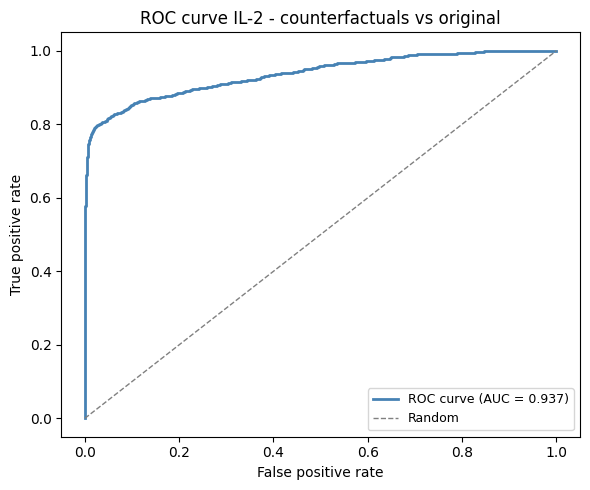

AUC: 0.937


In [ ]:
cfs_classifier.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in cfs_test_dataloader:
        x = x.to(analyzer.device)
        logits = cfs_classifier(x)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y[0].argmax(dim=1).cpu().numpy())  # one-hot to int

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# for binary classifier: use probability of positive class
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, target_idx])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curve {key} - counterfactuals vs original")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"roc_curve_{key}.png"), dpi=300)
plt.show()

print(f"AUC: {roc_auc:.3f}")

### 3.5 MMD

In [ ]:
ctrl_mmd = ctrl_mmd_dists(analyzer, key=key)
print(f"Control MMD (random split): {ctrl_mmd:.4f}")
global_mmd, mmd_per_group = mmd_dists(analyzer, key=key, sigma=1.0, cf_fn=generate_counterfactuals_scvi)
print(f"Global MMD for {key}: {global_mmd}")

Control MMD (random split): 0.0004
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:24<00:00,  2.25s/it]

Global MMD for IL-2: 0.010487914085388184


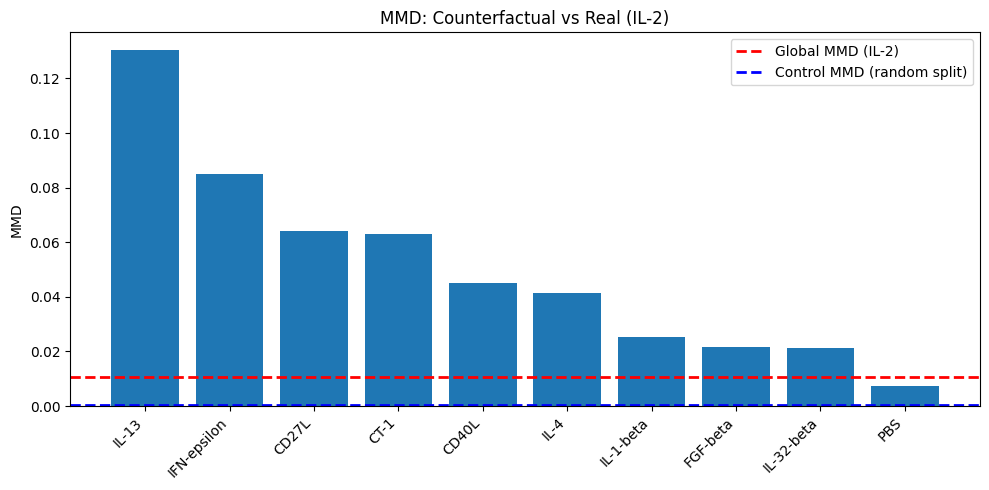

In [ ]:
plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key)

### 3.6 Mean Expressions

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

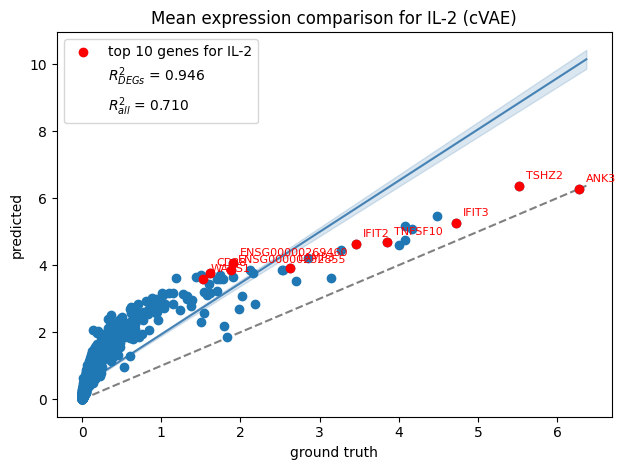

In [ ]:
plot_mean_expression_comparison(analyzer, key=key, top_n=10, cfs_fn=generate_counterfactuals_scvi, method="cVAE", log1p_transform = True)

### 3.7 Violin Plots

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

/home/jhoefer/sandbox/src/analysis/cf_expressions.py:283: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


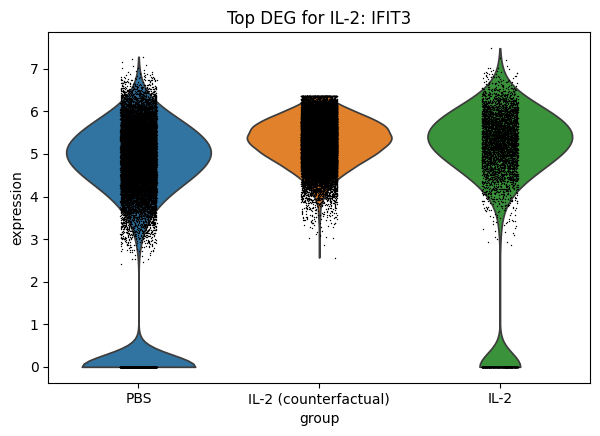

In [ ]:
plot_top_deg_violin(analyzer, key=key, cfs_fn=generate_counterfactuals_scvi, log1p_transform=True)

## 4. OOD

In [13]:
print(f"Holdout combo: {HOLDOUT_COMBO}")
print(f"Combo categories: {combo_categories}")

estimate_leftout_combo_mean(
    model=analyzer.model,
    combo_categories=combo_categories,
    conditions=combo_conditions,
    holdout_combo=HOLDOUT_COMBO,
    condition_key=labels_key,
    control_label=control_label,
    cell_type_key="cell_type",
)

Holdout combo: {'cytokine': 'IL-2', 'cell_type': 'CD8 Memory'}
Combo categories: ['CD27L__B Intermediate/Memory', 'CD27L__B Naive', 'CD27L__CD14 Mono', 'CD27L__CD16 Mono', 'CD27L__CD4 Memory', 'CD27L__CD4 Naive', 'CD27L__CD8 Memory', 'CD27L__CD8 Naive', 'CD27L__HSPC', 'CD27L__ILC', 'CD27L__MAIT', 'CD27L__NK', 'CD27L__NK CD56bright', 'CD27L__NKT', 'CD27L__Plasmablast', 'CD27L__Treg', 'CD27L__cDC', 'CD27L__pDC', 'CD40L__B Intermediate/Memory', 'CD40L__B Naive', 'CD40L__CD14 Mono', 'CD40L__CD16 Mono', 'CD40L__CD4 Memory', 'CD40L__CD4 Naive', 'CD40L__CD8 Memory', 'CD40L__CD8 Naive', 'CD40L__HSPC', 'CD40L__ILC', 'CD40L__MAIT', 'CD40L__NK', 'CD40L__NK CD56bright', 'CD40L__NKT', 'CD40L__Plasmablast', 'CD40L__Treg', 'CD40L__cDC', 'CD40L__pDC', 'CT-1__B Intermediate/Memory', 'CT-1__B Naive', 'CT-1__CD14 Mono', 'CT-1__CD16 Mono', 'CT-1__CD4 Memory', 'CT-1__CD4 Naive', 'CT-1__CD8 Memory', 'CT-1__CD8 Naive', 'CT-1__HSPC', 'CT-1__ILC', 'CT-1__MAIT', 'CT-1__NK', 'CT-1__NK CD56bright', 'CT-1__NKT', '

tensor([ 3.5690, -0.4762, -3.3402,  ..., -0.0353, -5.4102,  6.2040],
       device='cuda:0', grad_fn=<AddBackward0>)

### 4.1 Sampling strategy 1: Normal around the estimated mean

Sample fresh latent points from an isotropic Normal centered on the mean estimated above,
then decode. Unlike SCGENMixturePriorWrapper, `SCVIMixturePriorWrapper.forward()` respects
`normalize_output` symmetrically in both directions - with the wrapper's default
`normalize_output=False` (matching `layer="counts"` registration and this notebook's
raw-count `adata.X`), `forward()` operates directly on raw counts with no log1p/expm1
translation needed, so the generic `sample_leftout_combo_normal`/`sample_leftout_combo_shift`
(same functions eoflow.ipynb uses for the INN) apply here unchanged.

In [14]:
adata_ood_normal = sample_leftout_combo_normal(
    model=analyzer.model,
    combo_categories=combo_categories,
    conditions=combo_conditions,
    holdout_combo=HOLDOUT_COMBO,
    condition_key=labels_key,
    control_label=control_label,
    cell_type_key="cell_type",
    n_samples=500,
    sigma=1.0,
    var=analyzer.adata.var,
)
adata_ood_normal

AnnData object with n_obs × n_vars = 500 × 1937
    obs: 'cytokine', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_counts', 'highly_variable_rank', 'variances', 'variances_norm'

### 4.2 Sampling strategy 2: encode control cells, shift, decode

Real `PBS`-treated cells of the held-out cell type, encoded, shifted by the same average
treatment-control latent shift used above, then decoded - carries over each real cell's
own latent structure instead of drawing fresh isotropic noise.

In [15]:
adata_ood_shift = sample_leftout_combo_shift(
    model=analyzer.model,
    adata=analyzer.adata,
    combo_categories=combo_categories,
    conditions=combo_conditions,
    holdout_combo=HOLDOUT_COMBO,
    condition_key=labels_key,
    control_label=control_label,
    cell_type_key="cell_type",
)
adata_ood_shift

AnnData object with n_obs × n_vars = 147 × 1937
    obs: 'cytokine', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_counts', 'highly_variable_rank', 'variances', 'variances_norm'

### 4.3 Evaluation: MMD and mean expressions

Compares both OOD sampling strategies against the real held-out-combo cells - present in
`analyzer.adata` (the full, un-holdout-filtered adata) even though the model never trained
on them. `scoped_analyzer_for_combo` restricts `.adata` to just the held-out cell type so
`analyzer.labels_key` (the single "cytokine" column) alone resolves to this combo, letting
the same MMD and mean-expression helpers used for the regular counterfactual evaluation
(section 3) be reused unchanged via `cfs_fn_from_adata`. `log1p_transform=True` for the
mean-expression/effect-size plots, matching section 3.6's own convention for this raw-count
model; MMD stays at its default (raw-count) scale, matching section 3.5.

In [16]:
ood_key = HOLDOUT_COMBO[labels_key]

scoped_analyzer = scoped_analyzer_for_combo(
    analyzer,
    HOLDOUT_COMBO,
    conditions=combo_conditions,
    condition_key=labels_key,
    cell_type_key="cell_type",
)

ood_predictions = {
    "Normal": adata_ood_normal,
    "Shift": adata_ood_shift,
}

print(f"Real held-out cells found: {scoped_analyzer.adata.obs[labels_key].value_counts()[ood_key]}")

Real held-out cells found: 28


100%|████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 29386.84it/s]


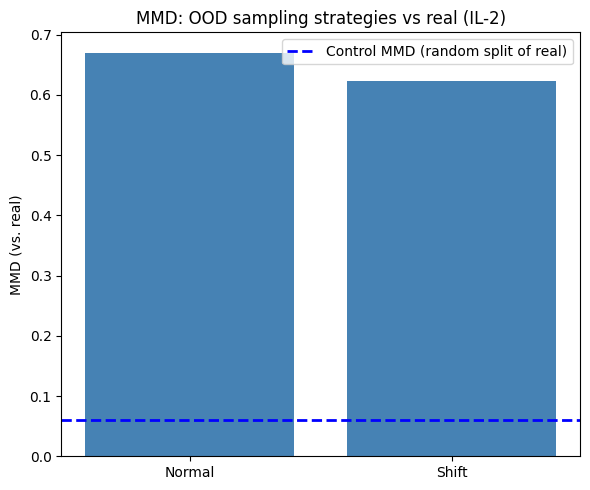

Control MMD (random split of real): 0.0600
{'Normal': 0.6702696084976196, 'Shift': 0.6232922673225403}


In [17]:
mmd_results, ood_ctrl_mmd = evaluate_leftout_combo_mmd(
    scoped_analyzer, ood_predictions, key=ood_key, plot_dir=analyzer.plot_dir
)
print(f"Control MMD (random split of real): {ood_ctrl_mmd:.4f}")
print(mmd_results)

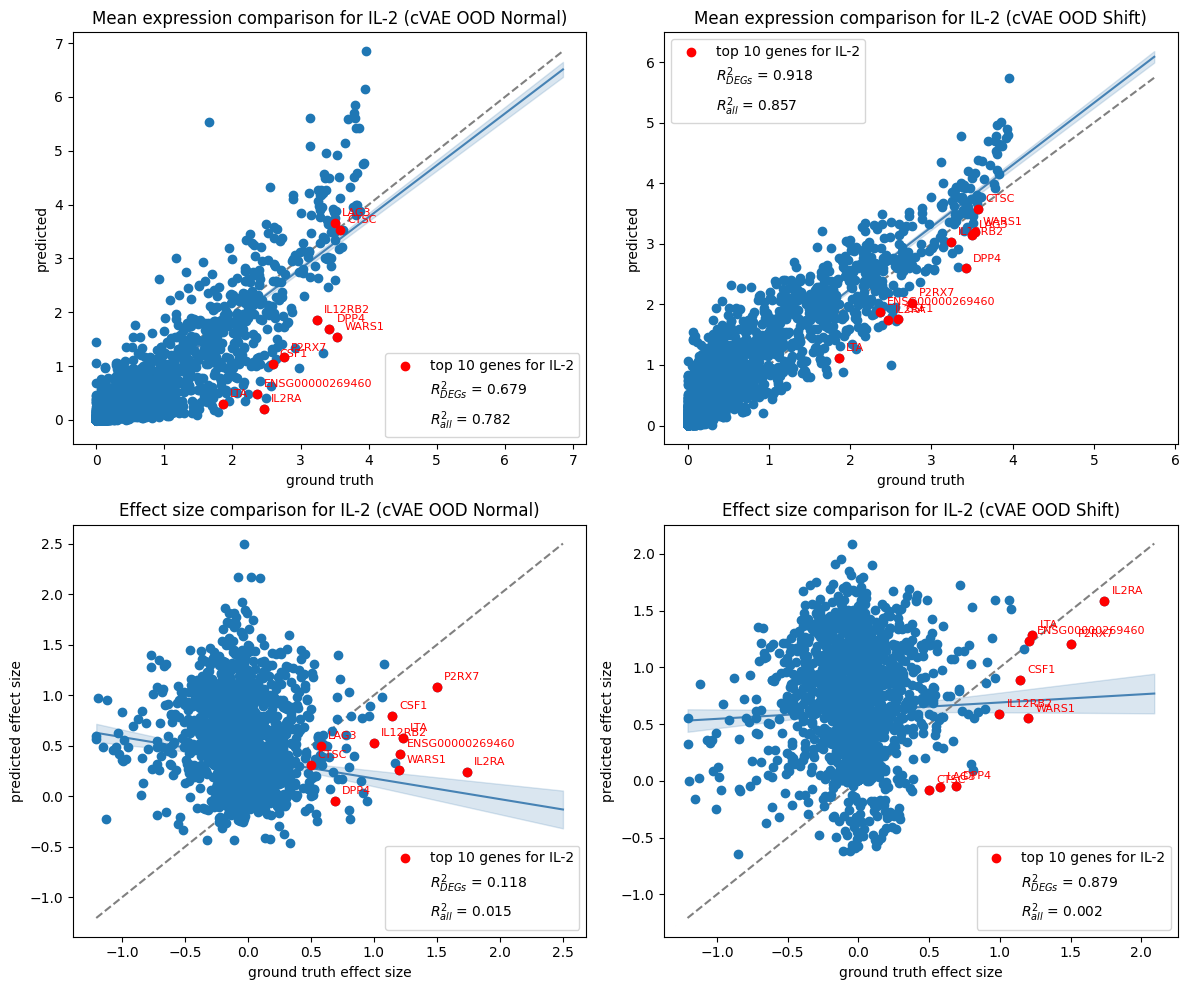

In [18]:
fig, axes = plt.subplots(2, len(ood_predictions), figsize=(6 * len(ood_predictions), 10))

for col, (name, adata_pred) in enumerate(ood_predictions.items()):
    cfs_fn = cfs_fn_from_adata(adata_pred, source_label=name)

    plot_mean_expression_comparison(
        scoped_analyzer,
        key=ood_key,
        top_n=10,
        cfs_fn=cfs_fn,
        log1p_transform=True,
        method=f"cVAE OOD {name}",
        ax=axes[0, col],
    )
    plot_effect_size_comparison(
        scoped_analyzer,
        key=ood_key,
        top_n=10,
        cfs_fn=cfs_fn,
        log1p_transform=True,
        method=f"cVAE OOD {name}",
        ax=axes[1, col],
    )

plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"leftout_combo_mean_expression_{ood_key}.png"), dpi=300)
plt.show()